In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import squareform,pdist
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from scipy.special import gamma

import sys
sys.path.append('../')
from src.embedding import Embedding
from src.markov_analysis import Markov
from src.viz import use_mpl_scatter_density

sys.path.append('../predictive_entropy/')
from HMM import (sample_hmm_gaussian,uniform_jump_chain,gaussian_volume)

def ellipse_from_cov(ax, mu, Sigma, c2=None, p=None, **patch_kw):
    mu = np.asarray(mu)
    # pick c^2 either directly or from confidence p
    if c2 is None:
        if p is None:
            p = 0.95
        c2 = chi2.ppf(p, df=2)

    # eig of covariance
    vals, vecs = np.linalg.eigh(Sigma)           # vals sorted ascending
    order = vals.argsort()[::-1]                 # descending: major first
    vals, vecs = vals[order], vecs[:, order]

    # axis lengths (radii) and rotation
    width, height = 2*np.sqrt(c2*vals)           # 2*radii
    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))

    e = Ellipse(xy=mu, width=width, height=height, angle=angle,
                fill=False, **patch_kw)
    ax.add_patch(e)
    return e, c2
def rand_cov_mat(N, d, var_min=0.1, var_max=1.0):
    cov_mats = []
    for _ in range(N):
        # Step 1: Sample eigenvalues (variances) in [sigma_min, sigma_max]
        eigenvalues = np.random.uniform(var_min, var_max, d)
        # Step 2: Generate a random orthogonal matrix (orientation)
        # Using QR decomposition on a random matrix
        H = np.random.randn(d, d)
        Q, _ = np.linalg.qr(H)

        # Step 3: Construct the covariance matrix: Q @ diag(eigenvalues) @ Q.T
        cov = Q @ np.diag(eigenvalues) @ Q.T
        cov_mats.append(cov)
    return np.array(cov_mats)

In [10]:
rng = np.random.default_rng(42)
d = 2
nc = 100
T = 1000
n_traj = 10
V_occ = 0.2
av_var = (V_occ/nc /unit_ball_volume(d) * 1/chi2.ppf(0.95, d))**(2./d)
var_min,var_max = av_var*0.9, av_var*1.1

# centers and covariances
means = np.random.uniform(0, 1, (nc, d))

#covs = np.stack([0.2*np.eye(d),
#                    0.3*np.array([[1.0, 0.5],[0.5, 1.0]]),
#                    0.1*np.eye(d)])

#sigma_min = (1/nc**2)/2
#sigma_max = (1/nc)/2
#var_min = sigma_min**2
#var_max = sigma_max**2
covs = rand_cov_mat(nc,d,var_min,var_max)

# sticky / uniform-jump chain
P = uniform_jump_chain(nc, alpha=0.05)
Z, X = sample_hmm_gaussian(P, means, covs, T, n_traj, rng=rng)
print("Hidden states shape:", Z.shape)  # (5, 200)
print("Observations shape:", X.shape)   # (5, 200, 2)
print(var_min)
print(var_max)

Hidden states shape: (10, 1000)
Observations shape: (10, 1000, 2)
9.562900533349302e-05
0.00011687989540760259


In [11]:
def unit_ball_volume(d):
    return (np.pi ** (d / 2) / gamma(d / 2 + 1))

def gaussian_volume(cov, p=0.95):
    d = cov.shape[0]
    c2 = chi2.ppf(p, d)  # quantile of chi^2_d
    V = unit_ball_volume(d) * (c2 ** (d / 2)) * np.sqrt(np.linalg.det(cov))
    return V

In [12]:
print('unit ball volume dimension 2 =',unit_ball_volume(2))
print('threshold for having 95% of the data =',chi2.ppf(0.95,2))
print("now check the eigen value drawn:")
sum_of_volumes = 0.
for cov in covs:
    val,eig = np.linalg.eigh(cov)
    print('--------------------------------------------')
    print('eigen values of the covariance matrix =',val)    
    print('determinant of the covariance matrix = ',np.linalg.det(cov))
    print()
    volume = np.linalg.det(cov)**0.5*unit_ball_volume(2)*chi2.ppf(0.95,2)
    sum_of_volumes+=volume
    print('volume of the ellipse = ',volume)
print()
print('--------------------------------------------')
print('--------------------------------------------')
print('volume final = ',sum_of_volumes)
mean_cov_range = 0.5 * (var_max-var_min)
print('to compare with the theoretical average = ',nc * unit_ball_volume(2)*chi2.ppf(0.95,2) * mean_cov_range**(d/2))


unit ball volume dimension 2 = 3.141592653589793
threshold for having 95% of the data = 5.991464547107979
now check the eigen value drawn:
--------------------------------------------
eigen values of the covariance matrix = [0.00011253 0.0001156 ]
determinant of the covariance matrix =  1.3008602433166399e-08

volume of the ellipse =  0.0021468326274981376
--------------------------------------------
eigen values of the covariance matrix = [0.00010813 0.00011574]
determinant of the covariance matrix =  1.251518237210851e-08

volume of the ellipse =  0.002105724052265315
--------------------------------------------
eigen values of the covariance matrix = [0.00010158 0.0001084 ]
determinant of the covariance matrix =  1.1011682853548956e-08

volume of the ellipse =  0.001975193801098471
--------------------------------------------
eigen values of the covariance matrix = [0.00011416 0.00011567]
determinant of the covariance matrix =  1.3205176721236406e-08

volume of the ellipse =  0.0021

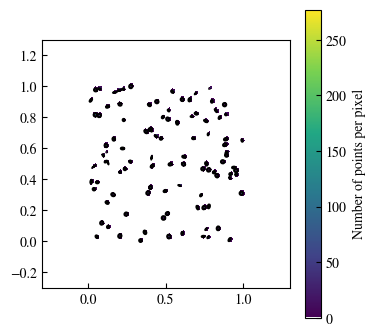

In [9]:
fig,ax = plt.subplots(figsize=(4,4),subplot_kw={'projection':'scatter_density'})
X_flat = X.reshape(-1,2)
#ax.scatter(X_flat[:,0],X_flat[:,1],s=1)
use_mpl_scatter_density(fig,X_flat[:,0],X_flat[:,1],ax=ax)
#ax.scatter(X[:,0], X[:,1], s=2, alpha=0.4)
for j in range(means.shape[0]):
    ellipse_from_cov(ax, mu=means[j], Sigma=covs[j], p=0.95, edgecolor='k', linewidth=1.5)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-0.3,1.3)
ax.set_ylim(-0.3,1.3)
plt.show()